In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_parquet('../data/model_data/model_data.parquet')
data.head()

,gender,under_30,senior_citizen,dependents,married,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_long_distance_charges,total_revenue,tenure,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,satisfaction_score,cltv,churn_label,extra_data_charges,referrals
0,2,0,0,0,1,1,1,0,1,0,1,1,0,0,3,3,1,2,65.6,42.39,593.30,381.51,974.81,9,0,16,1,2,3,2205,0,0,1
1,1,0,0,0,0,1,1,0,0,0,0,0,1,1,3,1,0,2,59.9,10.69,542.40,96.21,610.28,9,1,10,0,2,5,5414,0,1,0
2,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1,1,1,73.9,33.65,280.85,134.60,415.45,4,0,30,1,2,1,4479,1,0,0
3,1,0,1,0,1,1,1,0,1,1,0,1,1,0,1,1,1,1,98.0,27.82,1237.85,361.66,1599.51,13,0,4,1,3,1,3714,1,0,1
4,2,0,1,0,1,1,1,0,0,0,1,1,0,0,1,1,1,2,83.9,7.38,267.40,22.14,289.54,3,0,11,1,3,1,3464,1,0,1


In [3]:
import json
with open('note.txt', 'r') as file:
    f = file.read()
    info = json.loads(f)
info

{'shape': [7043, 51],
 'gender': {'1': 'Male', '2': 'Female'},
 'country': {'1': 'United States'},
 'state': {'1': 'California'},
 'internet_type': {'1': 'Fiber Optic', '2': 'DSL', '3': 'Cable'},
 'contract': {'1': 'Month-to-Month', '2': 'Two Year', '3': 'One Year'},
 'payment_method': {'1': 'Electronic check',
  '2': 'Mailed check',
  '3': 'Bank transfer (automatic)',
  '4': 'Credit card (automatic)'},
 'offer': {'1': 'Offer B',
  '2': 'Offer E',
  '3': 'Offer D',
  '4': 'Offer A',
  '5': 'Offer C'},
 'extra_data_charges': {'0': 'not_paid', '1': 'paid'},
 'referrals': {'0': 'not_referred',
  '1': 'referred_less_than_5',
  '2': 'referred_more_than_5'},
 'clean_shape': [7017, 42]}

In [4]:
info['gender']['1']

'Male'

In [5]:
with open('result.json', 'r') as res:
    r = res.read()
    result = json.loads(r)
result

{'decision_tree': {'accuracy': 0.9441595441595442,
  'best_params': {'criterion': 'entropy',
   'max_depth': 10,
   'min_samples_leaf': 5,
   'min_samples_split': 2}},
 'lr_model': {'accuracy': 0.9566951566951567,
  'best_params': {'C': 18.375468962060847,
   'class_weight': None,
   'max_iter': 1000,
   'penalty': 'l1',
   'solver': 'liblinear'}},
 'naive_bayes': {'accuracy': 0.8774928774928775,
  'best_params': {'var_smoothing': 1e-08}},
 'knn': {'accuracy': 0.7589743589743589,
  'best_params': {'n_neighbors': 8, 'p': 1, 'weights': 'uniform'}},
 'svm': {'accuracy': 0.9572649572649573,
  'best_params': {'C': 0.4418441521199725,
   'class_weight': None,
   'loss': 'squared_hinge',
   'penalty': 'l1'}}}

In [6]:
params = result['svm']['best_params']
print(params)

{'C': 0.4418441521199725, 'class_weight': None, 'loss': 'squared_hinge', 'penalty': 'l1'}


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.svm import LinearSVC
x = data.drop('churn_label', axis=1)
y = data['churn_label']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)
model = LinearSVC(max_iter=10000, C= 0.4418441521199725, class_weight= None, loss= 'squared_hinge', penalty= 'l1')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print('accuracy: ',accuracy_score(y_test, y_pred))

accuracy:  0.9572649572649573


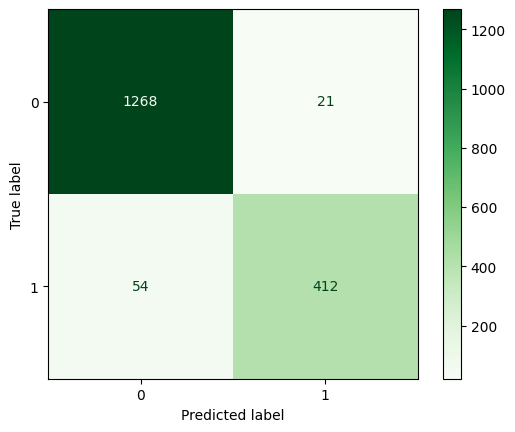

In [8]:
cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
cm.plot(cmap=plt.cm.Greens)

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1289
           1       0.95      0.88      0.92       466

    accuracy                           0.96      1755
   macro avg       0.96      0.93      0.94      1755
weighted avg       0.96      0.96      0.96      1755



In [ ]:
import joblib
joblib.dump(model, '../model/saved_svm_model.joblib')